# ch252 — Poisson Distribution

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. Rare Events in Large Trials

The Poisson distribution models **counts of rare events** in a fixed interval of time, space, or any other dimension.

Conditions for a Poisson process:
1. Events occur independently
2. The average rate λ is constant
3. Two events cannot occur at the exact same instant

It arises as the limit of Binomial(n, p) as n→∞, p→0, with np = λ fixed.

---

## 2. Derivation from Binomial

Take X ~ Binomial(n, λ/n). As n→∞:
$$P(X=k) = \binom{n}{k}\left(\frac{\lambda}{n}\right)^k\left(1-\frac{\lambda}{n}\right)^{n-k} \to \frac{\lambda^k e^{-\lambda}}{k!}$$

*(The exponential e^{-λ} = lim(1-λ/n)^n uses the exponential function from ch041.)*

The Poisson PMF:
$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0, 1, 2, \ldots$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import factorial, exp

def poisson_pmf(lam, k):
    """P(X=k) for X ~ Poisson(lambda). From scratch."""
    return (lam**k * exp(-lam)) / factorial(k)

# Verify against scipy
lam = 3.0
print("Poisson(λ=3) PMF:")
for k in range(12):
    ours = poisson_pmf(lam, k)
    ref  = stats.poisson.pmf(k, lam)
    bar  = '█' * int(ours * 60)
    print(f"  k={k:2d}: {ours:.5f}  {bar}")

Poisson(λ=3) PMF:
  k= 0: 0.04979  ██
  k= 1: 0.14936  ████████
  k= 2: 0.22404  █████████████
  k= 3: 0.22404  █████████████
  k= 4: 0.16803  ██████████
  k= 5: 0.10082  ██████
  k= 6: 0.05041  ███
  k= 7: 0.02160  █
  k= 8: 0.00810  
  k= 9: 0.00270  
  k=10: 0.00081  
  k=11: 0.00022  


## 3. Mean and Variance

For X ~ Poisson(λ):
$$E[X] = \lambda, \quad \text{Var}(X) = \lambda$$

The mean equals the variance — this is unique to the Poisson distribution and is a quick check: if a count variable has mean ≈ variance, Poisson is a reasonable model.

In [2]:
# Simulate Poisson processes and verify E[X] = Var(X) = lambda
rng = np.random.default_rng(seed=42)
n = 100_000

print(f"{'λ':>6} {'Sample Mean':>14} {'Sample Var':>12} {'Mean≈λ':>8} {'Var≈λ':>8}")
print("-" * 55)
for lam in [0.5, 1.0, 3.0, 10.0, 30.0]:
    samples = rng.poisson(lam, size=n)
    m = samples.mean()
    v = samples.var()
    print(f"{lam:>6.1f} {m:>14.4f} {v:>12.4f} {abs(m-lam)<0.05!s:>8} {abs(v-lam)<0.05!s:>8}")

     λ    Sample Mean   Sample Var   Mean≈λ    Var≈λ
-------------------------------------------------------
   0.5         0.5008       0.5004     True     True
   1.0         1.0014       1.0038     True     True
   3.0         2.9971       2.9844     True     True
  10.0        10.0160      10.0099     True     True
  30.0        29.9750      29.7557     True    False


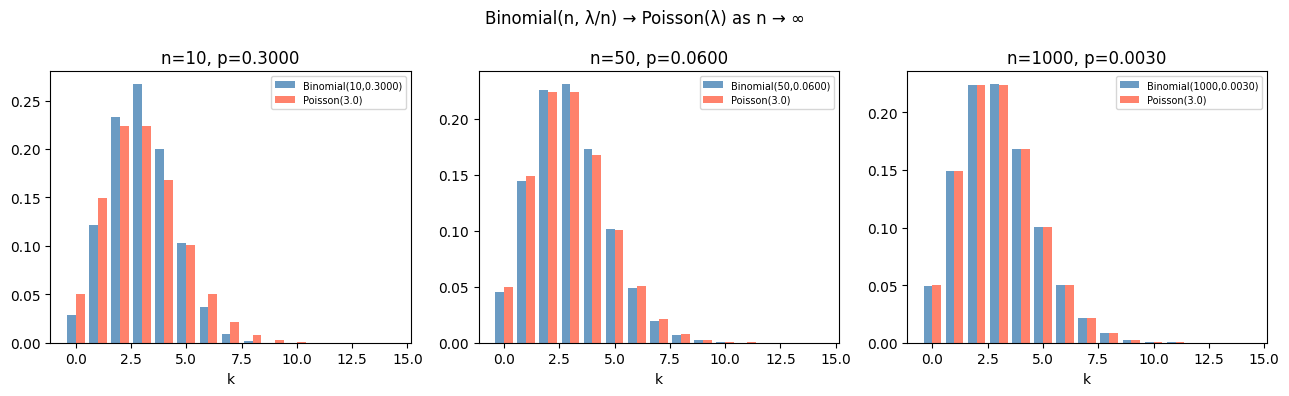

In [3]:
# Binomial -> Poisson convergence
lam = 3.0
k_range = np.arange(0, 15)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, n in zip(axes, [10, 50, 1000]):
    p = lam / n
    binom_pmf = stats.binom.pmf(k_range, n, p)
    pois_pmf  = stats.poisson.pmf(k_range, lam)
    
    ax.bar(k_range - 0.2, binom_pmf, width=0.4, alpha=0.8, color='steelblue', label=f'Binomial({n},{p:.4f})')
    ax.bar(k_range + 0.2, pois_pmf,  width=0.4, alpha=0.8, color='tomato',    label=f'Poisson({lam})')
    ax.set_title(f'n={n}, p={p:.4f}')
    ax.set_xlabel('k')
    ax.legend(fontsize=7)

plt.suptitle('Binomial(n, λ/n) → Poisson(λ) as n → ∞', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Poisson Process Applications

In [4]:
# Application 1: Server requests
# A web server receives 120 requests/minute on average.
# What is P(>130 requests in a given minute)?

lam_server = 120  # average requests per minute
threshold = 130

rv = stats.poisson(lam_server)
p_exceed = 1 - rv.cdf(threshold)
print(f"Server load: λ={lam_server} requests/min")
print(f"P(X > {threshold}) = {p_exceed:.6f} ({p_exceed*100:.3f}%)")

# Application 2: Inter-arrival times follow Exponential distribution
# If events arrive at rate λ, the time between events is Exponential(λ)
# P(wait > t) = exp(-λt)

lam_arrivals = 2.0  # 2 events per minute
t_wait = 1.0        # wait time in minutes

p_wait_over_t = np.exp(-lam_arrivals * t_wait)
print(f"\nInter-arrival: λ={lam_arrivals}/min")
print(f"P(wait > {t_wait} min) = exp(-{lam_arrivals}×{t_wait}) = {p_wait_over_t:.4f}")

# Simulate inter-arrival times
rng = np.random.default_rng(seed=0)
n_sim = 100_000
inter_arrivals = rng.exponential(scale=1/lam_arrivals, size=n_sim)
print(f"Simulated P(wait > {t_wait}) = {(inter_arrivals > t_wait).mean():.4f}")

Server load: λ=120 requests/min
P(X > 130) = 0.168518 (16.852%)

Inter-arrival: λ=2.0/min
P(wait > 1.0 min) = exp(-2.0×1.0) = 0.1353
Simulated P(wait > 1.0) = 0.1353


## 5. Poisson Regression Preview

When modeling count data (number of defects, number of accidents, number of page views), the Poisson distribution provides the likelihood function. Poisson regression models log(λ) as a linear function of features — this is a generalized linear model used throughout data science.

In [5]:
# Overdispersion check: real count data often has Var > Mean (overdispersed)
# This violates the Poisson assumption and signals a different model is needed

# Underdispersed (Poisson): traffic accidents at a junction
lam = 2.0
n_days = 1000
rng = np.random.default_rng(seed=42)

poisson_data = rng.poisson(lam, size=n_days)
print("Poisson data (accidents per day):")
print(f"  Mean = {poisson_data.mean():.4f}   (expected: {lam})")
print(f"  Var  = {poisson_data.var():.4f}   (expected: {lam})")
print(f"  Var/Mean = {poisson_data.var()/poisson_data.mean():.4f}  (Poisson: should ≈ 1)")

Poisson data (accidents per day):
  Mean = 2.0090   (expected: 2.0)
  Var  = 2.0049   (expected: 2.0)
  Var/Mean = 0.9980  (Poisson: should ≈ 1)


## 6. Summary

- Poisson(λ) models the count of rare independent events in a fixed interval.
- PMF: P(X=k) = λ^k · e^{−λ} / k!.
- E[X] = Var(X) = λ — the Poisson's defining property.
- It is the limit of Binomial(n, λ/n) as n→∞.
- Inter-arrival times in a Poisson process are Exponential(λ).

---

## 7. Forward References

The Poisson distribution is the foundation of Poisson regression (a generalized linear model) covered in Part IX statistics. It connects to the exponential distribution, which appears in survival analysis and queuing theory. The normal approximation to the Poisson (valid for large λ) is another instance of the Central Limit Theorem (ch254).